In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the local file (since it is in the same folder, you just need the name)
df = pd.read_csv("Telco-Customer-Churn.csv") 

# Display initial check
print("Dataset successfully loaded!")
print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")
df.head()


Dataset successfully loaded!
Total Rows: 7043 | Total Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# 1. Check for missing values across columns
print("Missing values per column:")
print(df.isnull().sum())

# 2. Fix the 'TotalCharges' data type
# The Telco dataset contains blank spaces ' ' in TotalCharges which forces Python to read it as text.
# 'errors=coerce' converts those blank spaces into NaN (null) values.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Fill the newly created NaNs in TotalCharges with 0 (since their tenure is 0)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 4. Drop the customerID column as it is a unique string and won't help us find patterns
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# 5. Convert the target variable 'Churn' to numbers (Yes = 1, No = 0)
# This allows Seaborn to calculate correlations and plot risk percentages later
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("\nData cleaning complete!")
print("New data types for key columns:")
print(df[['TotalCharges', 'Churn']].dtypes)


Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data cleaning complete!
New data types for key columns:
TotalCharges    float64
Churn             int64
dtype: object


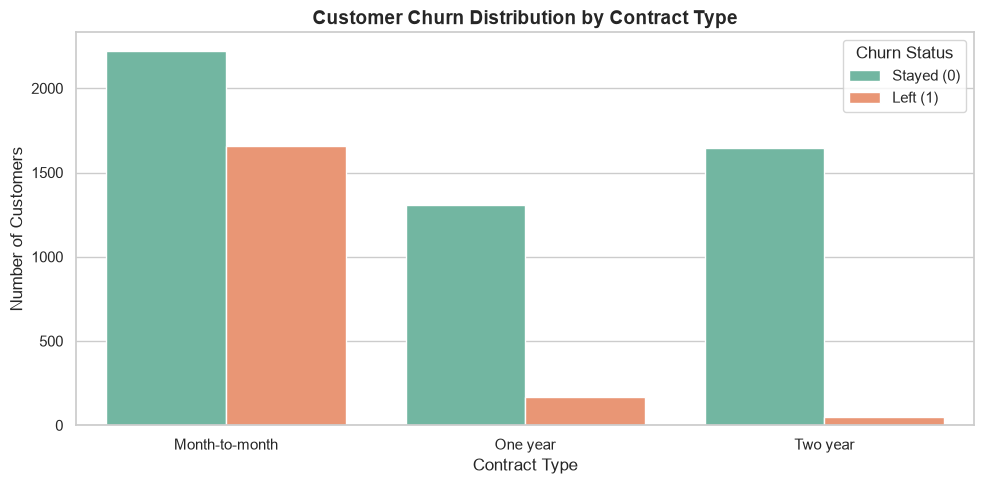

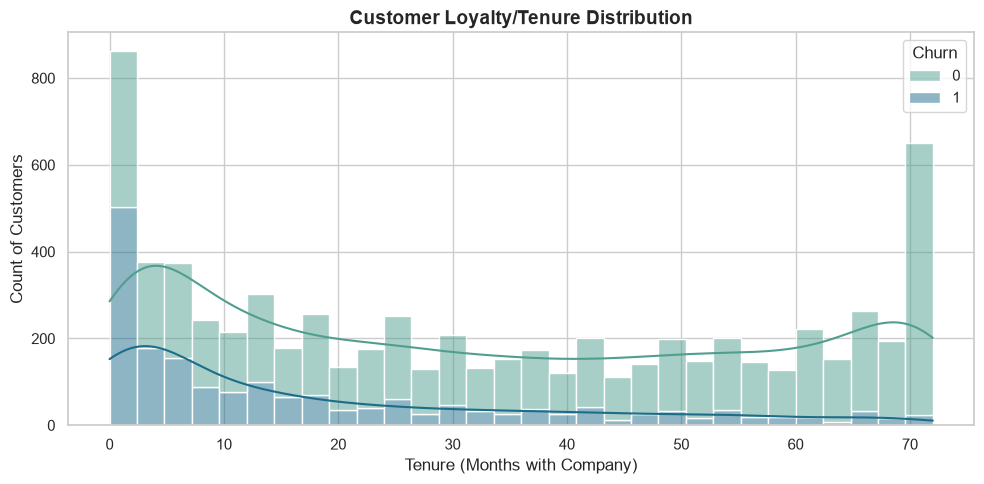

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for your charts
sns.set_theme(style="whitegrid")

# ----------------------------------------------------
# PLOT 1: Churn by Contract Type (The biggest risk factor)
# ----------------------------------------------------
plt.figure(figsize=(10, 5))
# We use Churn as the 'hue' to split the bars into those who stayed vs those who left
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')

plt.title('Customer Churn Distribution by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Churn Status', labels=['Stayed (0)', 'Left (1)'])
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# PLOT 2: Customer Tenure vs Churn (When do they leave?)
# ----------------------------------------------------
plt.figure(figsize=(10, 5))
# A histogram with a density curve shows exactly at what month customers drop off
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, multiple='stack', palette='crest', bins=30)

plt.title('Customer Loyalty/Tenure Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months with Company)', fontsize=12)
plt.ylabel('Count of Customers', fontsize=12)
plt.tight_layout()
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_1336\2827577382.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')


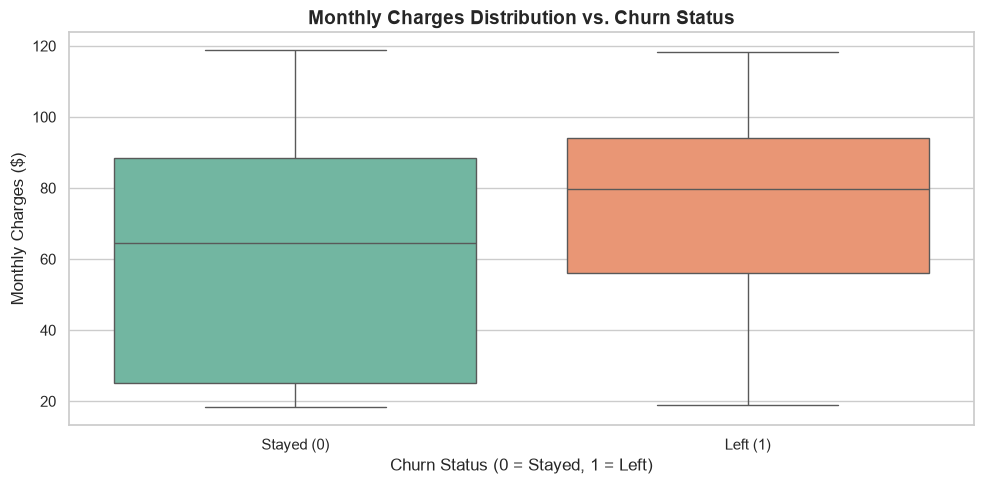

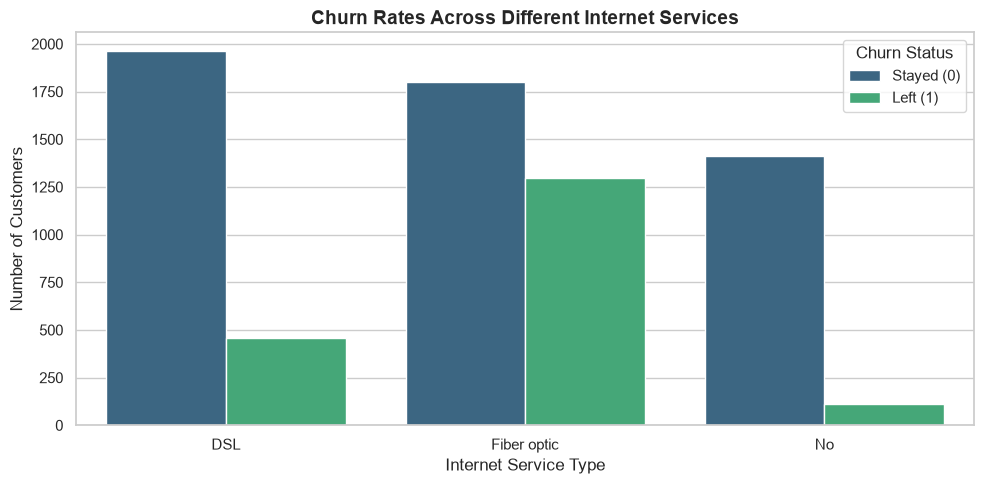

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------
# PLOT 3: Monthly Charges vs Churn (Financial Impact)
# ----------------------------------------------------
plt.figure(figsize=(10, 5))
# A boxplot shows the median, quartiles, and distribution of monthly bills for both groups
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')

plt.title('Monthly Charges Distribution vs. Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status (0 = Stayed, 1 = Left)', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)
plt.xticks([0, 1], ['Stayed (0)', 'Left (1)'])
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# PLOT 4: Internet Service vs Churn (Service Drivers)
# ----------------------------------------------------
plt.figure(figsize=(10, 5))
# Checking if specific technology types have higher failure/churn rates
sns.countplot(x='InternetService', hue='Churn', data=df, palette='viridis')

plt.title('Churn Rates Across Different Internet Services', fontsize=14, fontweight='bold')
plt.xlabel('Internet Service Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(title='Churn Status', labels=['Stayed (0)', 'Left (1)'])
plt.tight_layout()
plt.show()


In [7]:
# Calculate exact churn percentages for key drivers to back up your charts

print("=== 1. CHURN RATE BY CONTRACT TYPE ===")
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
print(contract_churn.round(2).astype(str) + '%')

print("\n=== 2. CHURN RATE BY INTERNET SERVICE ===")
internet_churn = df.groupby('InternetService')['Churn'].mean() * 100
print(internet_churn.round(2).astype(str) + '%')

print("\n=== 3. AVERAGE MONTHLY CHARGES ===")
charges_churn = df.groupby('Churn')['MonthlyCharges'].mean()
print(f"Average bill of customers who STAYED: ${charges_churn[0]:.2f}")
print(f"Average bill of customers who CHURNED: ${charges_churn[1]:.2f}")


=== 1. CHURN RATE BY CONTRACT TYPE ===
Contract
Month-to-month    42.71%
One year          11.27%
Two year           2.83%
Name: Churn, dtype: str

=== 2. CHURN RATE BY INTERNET SERVICE ===
InternetService
DSL            18.96%
Fiber optic    41.89%
No               7.4%
Name: Churn, dtype: str

=== 3. AVERAGE MONTHLY CHARGES ===
Average bill of customers who STAYED: $61.27
Average bill of customers who CHURNED: $74.44
